# Week 8 

This week's curriculum is about text analysis. The overview is

* Finding the important words in a document (TF-IDF)
* Apply these tricks to understand what different communities in Computational Social Science are working on. 


# Part 1 - Words that characterize Computational Social Science communities

In this class, we'll play around with how far we can get with simple strategies for looking at text. The video is Sune talking about a fun paper, which shows you how little is needed in order to reveal something very interesting about humans that produce text. Then, we'll use a simple weighting scheme called TF-IDF to find the words in the Computational Social Science papers that charachterize different communities. Finally, we'll visualize using word clouds (below is what I found). The wordclouds may not be immediately understandable. But if you do some research on the important words, you will find that the TF-IDF method extracts quite interesting information.

<img src="https://github.com/lalessan/comsocsci2026/blob/master/figures/tf_idf.png?raw=true" alt="Drawing" style="width: 1000px;"/>


> **Video lecture**: Simple methods reveal a lot. Sune talks a little bit about the paper: [Personality, Gender, and Age in the Language of Social Media: The Open-Vocabulary Approach](http://journals.plos.org/plosone/article?id=10.1371/journal.pone.0073791).  

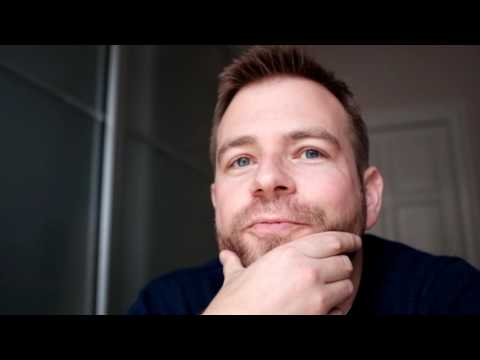

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("wkYvdfkVmlI",width=800, height=450)

> __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
> What you need for this exercise: 
>.   
>    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
>    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)
>
> 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
>   * What does TF stand for? 
>   * What does IDF stand for?
> 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
>   * Consider a community _c_
>   * Find all the abstracts of papers written by a member of community _c_.
>   * Create a long array that stores all the abstract tokens 
>   * Repeat for all the communities. 
> __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.api.typing.DataFrameGroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).
> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 
>   * Describe similarities and differences between the communities.
>   * Why aren't the TFs not necessarily a good description of the communities?
>   * Next, we calculate IDF for every word. 
>   * What base logarithm did you use? Is that important?
> 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
>   * List the 10 top TF words 
>   * List the 10 top TF-IDF words
>   * List the top 3 authors (by degree)
>   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?


# Exercise 1

## 1.

The terms TF and IDF stand for term frequency and inverse document frequency, respectively. Both are measures to quantify the relevance of a word to a document in a corpus of documents. The former measures how often a specific term $t$ appears in a given document $d$ divided by the total amount of terms $t'$ in $d$, hence 'frequency', ie
\begin{equation}
    tf(t,d) = \frac{f_{t,d}}{\sum_{t'\in d}f_{t',d}}
\end{equation}

This term is useful for capturing local importance within an individual document.
The latter, inverse document frequency, measures how rare a term is across the entire collection of documents. It is originally given by
\begin{equation}
    idf(t,D) = log \frac{N}{n_t}
\end{equation}
Where $D$ denotes the set of all documents in a given corpus, $N=|D|$ denotes the total number of documents in a corpus, and $n_t=|\{d\in D:t \in d\}|$ denotes the number of documents where the term $t$ appears, ie $tf(t,d) \neq 0$. However, if the term is not in the corpus, $n_t=0$ and lead to a division by $0$. Therefore, it is common to append 1 to both the numerator and denominator instead:
\begin{equation}
    idf(t,D) = log \frac{N+1}{n_t+1}
\end{equation}
The IDF measures how common a term is across the entire corpus. A rare term will yield a high IDF value and vice versa. 

## 2.

In [2]:
import json
import numpy as np
import pandas as pd
import networkx as nx
from collections import Counter, defaultdict
from math import log
import ast

In [3]:
# --- 1. Load network → build GCC, compute degrees, run Louvain ---
with open("css_network.json", "r") as f:
    net_data = json.load(f)
 
G = nx.node_link_graph(net_data)
G_undirected = G.to_undirected() if G.is_directed() else G
gcc_nodes = max(nx.connected_components(G_undirected), key=len)
G_gcc = G_undirected.subgraph(gcc_nodes).copy()
 
nodes_raw = net_data.get("nodes", [])
print(f"  Network: {len(nodes_raw)} total nodes, GCC: {G_gcc.number_of_nodes()} nodes")
 
# Degree for each node (keyed by OpenAlex URL)
node_degrees = dict(G_gcc.degree())
 
# --- 2. Run Louvain community detection on the CSS GCC ---
# (The css_community_assignments.json only has 34 entries — it was
#  accidentally saved from the Karate Club exercise, not the CSS network.
#  So we re-run Louvain here on the actual CSS network.)
import community as community_louvain
 
partition = community_louvain.best_partition(G_gcc, random_state=42)
Q = community_louvain.modularity(partition, G_gcc)
n_communities = len(set(partition.values()))
 
print(f"  Louvain communities: {n_communities}, modularity Q = {Q:.4f}")
 
# partition maps OpenAlex URL → community label
# Build: OpenAlex URL → community
url_to_community = partition  # already keyed by OpenAlex URLs
 
community_sizes = Counter(partition.values())
print(f"\n  Community sizes (top 10):")
for comm_id, size in community_sizes.most_common(10):
    print(f"    Community {comm_id}: {size} authors")
 
# --- 3. Load papers and abstracts ---
papers_df = pd.read_csv("D5_coauthor_papers.csv")
abstracts_df = pd.read_csv("abstracts_with_collocations.csv")
 
print(f"\n  Papers:    {papers_df.shape[0]} rows, columns: {list(papers_df.columns)}")
print(f"  Abstracts: {abstracts_df.shape[0]} rows, columns: {list(abstracts_df.columns)}")
print(f"  Same number of rows: {papers_df.shape[0] == abstracts_df.shape[0]}")

  Network: 21693 total nodes, GCC: 21002 nodes
  Louvain communities: 84, modularity Q = 0.8439

  Community sizes (top 10):
    Community 11: 1299 authors
    Community 12: 781 authors
    Community 9: 759 authors
    Community 23: 756 authors
    Community 6: 749 authors
    Community 16: 749 authors
    Community 14: 656 authors
    Community 30: 534 authors
    Community 49: 517 authors
    Community 0: 487 authors

  Papers:    39450 rows, columns: ['id', 'publication_year', 'cited_by_count', 'author_ids']
  Abstracts: 10375 rows, columns: ['title', 'text', 'tokens_clean', 'bigrams', 'tokens_mwe']
  Same number of rows: False


In [5]:
# Join papers + abstracts by index (they are aligned: same papers, same order)
combined_df = papers_df.copy()
combined_df["tokens_mwe"] = abstracts_df["tokens_mwe"]
 
# Parse author_ids from string to list
combined_df["author_list"] = combined_df["author_ids"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)
 
# Explode: one row per (paper, author) pair
exploded = combined_df.explode("author_list").dropna(subset=["author_list"])
print(f"  After exploding author_ids: {len(exploded)} (paper, author) rows")
 
# Map author OpenAlex URL directly to community (both are keyed by URL now)
exploded["community"] = exploded["author_list"].map(url_to_community)
 
# Keep only rows where author is in a known community (i.e., in the GCC)
n_before = len(exploded)
exploded = exploded.dropna(subset=["community"])
exploded["community"] = exploded["community"].astype(int)
 
print(f"  Rows with community assignment: {len(exploded)} / {n_before}")
print(f"  Unique authors matched: {exploded['author_list'].nunique()}")
print(f"  Unique communities: {sorted(exploded['community'].unique())}")

  After exploding author_ids: 89991 (paper, author) rows
  Rows with community assignment: 89761 / 89991
  Unique authors matched: 11743
  Unique communities: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(6

In [6]:
# Parse tokens and build community documents
exploded["parsed_tokens"] = exploded["tokens_mwe"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("[") else []
)
 
# Efficient pandas: explode + groupby
community_docs = (
    exploded[["community", "parsed_tokens"]]
    .explode("parsed_tokens")
    .dropna(subset=["parsed_tokens"])
    .groupby("community")["parsed_tokens"]
    .apply(list)
    .to_dict()
)
 
print(f"\n  Community documents created: {len(community_docs)} communities\n")
for comm_id in sorted(community_docs.keys()):
    tokens = community_docs[comm_id]
    print(f"    Community {comm_id}: {len(tokens):>8,} tokens, {len(set(tokens)):>6,} unique")


  Community documents created: 78 communities

    Community 0:   31,418 tokens,  5,188 unique
    Community 1:   42,406 tokens,  5,999 unique
    Community 2:   43,956 tokens,  5,994 unique
    Community 3:   23,304 tokens,  3,952 unique
    Community 4:   12,608 tokens,  2,871 unique
    Community 5:   48,720 tokens,  6,254 unique
    Community 6:  120,433 tokens, 10,065 unique
    Community 7:   28,270 tokens,  4,488 unique
    Community 8:    2,955 tokens,  1,140 unique
    Community 9:  133,680 tokens, 10,454 unique
    Community 10:   70,814 tokens,  7,129 unique
    Community 11:  146,665 tokens, 10,900 unique
    Community 12:   69,227 tokens,  7,464 unique
    Community 13:   56,728 tokens,  6,430 unique
    Community 14:  119,216 tokens,  9,951 unique
    Community 15:    5,165 tokens,  1,508 unique
    Community 16:   47,261 tokens,  6,431 unique
    Community 17:   47,604 tokens,  6,246 unique
    Community 18:   45,823 tokens,  6,168 unique
    Community 19:   17,236 toke

## TF and IDF

In [9]:
# --- Community sizes by number of authors ---
community_author_counts = Counter(url_to_community.values())
top5_communities = [c for c, _ in community_author_counts.most_common(5)]
top9_communities = [c for c, _ in community_author_counts.most_common(9)]
 
print("  Communities ranked by number of authors:")
for rank, (comm, count) in enumerate(community_author_counts.most_common(), 1):
    print(f"    #{rank}: Community {comm} — {count} authors")

  Communities ranked by number of authors:
    #1: Community 11 — 1299 authors
    #2: Community 12 — 781 authors
    #3: Community 9 — 759 authors
    #4: Community 23 — 756 authors
    #5: Community 6 — 749 authors
    #6: Community 16 — 749 authors
    #7: Community 14 — 656 authors
    #8: Community 30 — 534 authors
    #9: Community 49 — 517 authors
    #10: Community 0 — 487 authors
    #11: Community 13 — 467 authors
    #12: Community 1 — 455 authors
    #13: Community 42 — 451 authors
    #14: Community 54 — 450 authors
    #15: Community 31 — 442 authors
    #16: Community 33 — 439 authors
    #17: Community 10 — 430 authors
    #18: Community 34 — 425 authors
    #19: Community 2 — 410 authors
    #20: Community 36 — 406 authors
    #21: Community 5 — 387 authors
    #22: Community 21 — 385 authors
    #23: Community 61 — 365 authors
    #24: Community 60 — 334 authors
    #25: Community 18 — 315 authors
    #26: Community 3 — 305 authors
    #27: Community 28 — 302 authors


In [10]:
# --- Compute TF ---
# TF(t, c) = count(t in community c) / total_tokens(community c)
tf = {}
for comm_id, tokens in community_docs.items():
    total = len(tokens)
    word_counts = Counter(tokens)
    tf[comm_id] = {word: count / total for word, count in word_counts.items()}
 
# --- Top 5 TF terms for top 5 communities ---
print("\n  ── Top 5 TF terms for the Top 5 communities ──\n")
for comm_id in top5_communities:
    if comm_id not in tf:
        continue
    top_words = sorted(tf[comm_id].items(), key=lambda x: -x[1])[:5]
    n_authors = community_author_counts[comm_id]
    print(f"  Community {comm_id} ({n_authors} authors):")
    for word, score in top_words:
        print(f"    {word:<30s}  TF = {score:.6f}")
    print()


  ── Top 5 TF terms for the Top 5 communities ──

  Community 11 (1299 authors):
    information                     TF = 0.004684
    social                          TF = 0.003614
    research                        TF = 0.003409
    results                         TF = 0.003205
    different                       TF = 0.002741

  Community 12 (781 authors):
    information                     TF = 0.004319
    research                        TF = 0.003424
    social                          TF = 0.003351
    different                       TF = 0.003164
    results                         TF = 0.003135

  Community 9 (759 authors):
    information                     TF = 0.003755
    research                        TF = 0.003591
    social                          TF = 0.003291
    different                       TF = 0.002768
    people                          TF = 0.002745

  Community 23 (756 authors):
    information                     TF = 0.004041
    research              

Generic internet terms like social, information, and research dominate across *Communities* as they are common in the field.

TF alone is not a good description. It only measures local frequency. Words common everywhere dominate
  every community's ranking. They describe the *field*, not the *community*.
  We need IDF to downweight these ubiquitous terms.

In [12]:
# --- Compute IDF ---
N = len(community_docs)  # total number of "documents" (communities)
 
doc_freq = Counter()
for comm_id, tokens in community_docs.items():
    unique_words = set(tokens)
    for word in unique_words:
        doc_freq[word] += 1
 
# Natural logarithm (base e)
idf = {word: log(N / df) for word, df in doc_freq.items()}
 
print(f"  IDF computed for {len(idf):,} unique terms across {N} communities")
print(f"  Logarithm base: natural log (base e)")
print(f"  Max IDF (word in 1 community)    : ln({N}/1) = {log(N/1):.4f}")
print(f"  Min IDF (word in all communities): ln({N}/{N}) = {log(N/N):.4f} = 0")

  IDF computed for 35,221 unique terms across 78 communities
  Logarithm base: natural log (base e)
  Max IDF (word in 1 community)    : ln(78/1) = 4.3567
  Min IDF (word in all communities): ln(78/78) = 0.0000 = 0


Note: The choice of log base does NOT affect rankings
$$log_b(x) = ln(x)/ln(b)$$
so it's just a constant scaling factor."

In [16]:
# --- Compute TF-IDF ---
tfidf = {}
for comm_id in community_docs:
    tfidf[comm_id] = {
        word: tf_val * idf.get(word, 0)
        for word, tf_val in tf[comm_id].items()
    }
 
# --- Display results ---
for comm_id in top9_communities:
    if comm_id not in tf or comm_id not in tfidf:
        continue
 
    n_authors = community_author_counts[comm_id]
    print("=" * 70)
    print(f"  Community {comm_id}  ({n_authors} authors)")
    print("=" * 70)
 
    # Top 10 TF words
    top_tf = sorted(tf[comm_id].items(), key=lambda x: -x[1])[:10]
    print(f"\n  Top 10 TF words:")
    for rank, (word, score) in enumerate(top_tf, 1):
        print(f"    {rank:>2}. {word:<30s}  TF = {score:.6f}")
 
    # Top 10 TF-IDF words
    top_tfidf = sorted(tfidf[comm_id].items(), key=lambda x: -x[1])[:10]
    print(f"\n  Top 10 TF-IDF words:")
    for rank, (word, score) in enumerate(top_tfidf, 1):
        print(f"    {rank:>2}. {word:<30s}  TF-IDF = {score:.6f}")
 
    # Top 3 authors by degree
    community_members = [
        url for url, comm in url_to_community.items()
        if comm == comm_id and url in node_degrees
    ]
    members_by_degree = sorted(
        community_members, key=lambda u: node_degrees.get(u, 0), reverse=True
    )[:3]
 
    print(f"\n  Top 3 authors by degree:")
    for url in members_by_degree:
        deg = node_degrees.get(url, 0)
        display = G_gcc.nodes[url].get("display_name", url) if url in G_gcc.nodes else url
        print(f"    {display} — degree {deg}")
    print()

  Community 11  (1299 authors)

  Top 10 TF words:
     1. information                     TF = 0.004684
     2. social                          TF = 0.003614
     3. research                        TF = 0.003409
     4. results                         TF = 0.003205
     5. different                       TF = 0.002741
     6. users                           TF = 0.002727
     7. people                          TF = 0.002509
     8. models                          TF = 0.002475
     9. time                            TF = 0.002393
    10. network                         TF = 0.002359

  Top 10 TF-IDF words:
     1. portman                         TF-IDF = 0.002079
     2. coussins                        TF-IDF = 0.001010
     3. aerc                            TF-IDF = 0.001010
     4. ews                             TF-IDF = 0.000951
     5. sves                            TF-IDF = 0.000802
     6. sleep                           TF-IDF = 0.000772
     7. bcts                         

 TF-IDF words are much more descriptive of each community.
 
IDF downweights words that appear across many/all communities:
  • Generic words: high TF × low IDF  → low TF-IDF  (filtered out)
  • Distinctive words: high TF × high IDF → high TF-IDF (promoted)
 
This surfaces the *characterizing* vocabulary of each community, ie. the words that make it *different* from the others.

 __Exercise 2: The Wordcloud__. It's time to visualize our results!

> * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
> * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 
> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


/var/folders/4p/ys3rkz1x60xcwx4pzd453jt40000gn/T/ipykernel_22367/4284145362.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


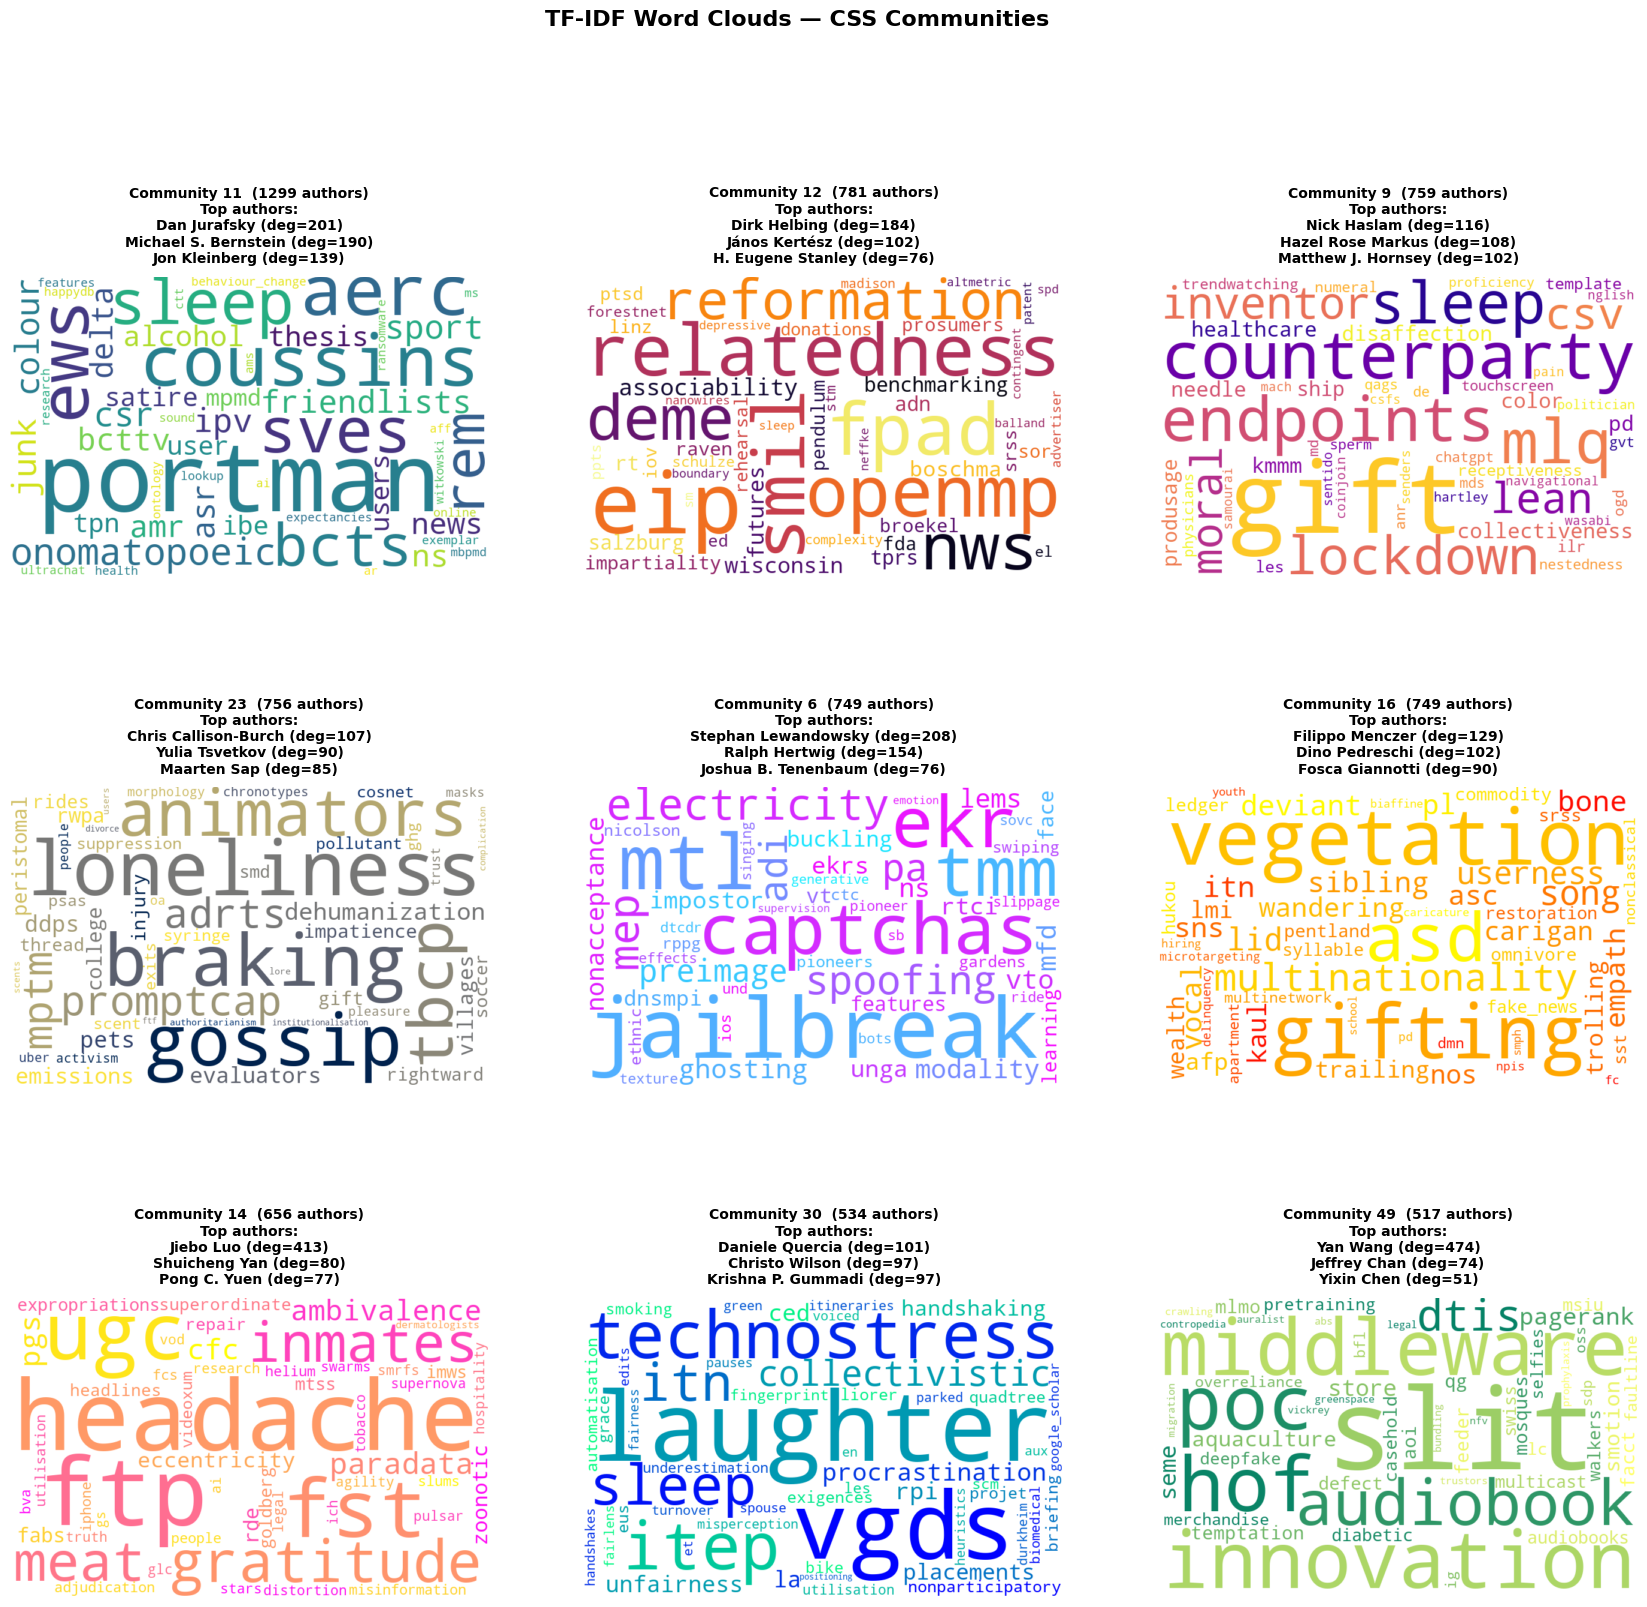

  Word clouds saved to css_wordclouds.png


In [19]:
# Use top 9 communities (or fewer if less exist)
comms_to_plot = [c for c in top9_communities if c in tfidf]
 
# ── Color palettes for each community (to make them visually distinct) ────────
color_maps = [
    "viridis", "inferno", "plasma", "cividis",
    "cool", "autumn", "spring", "winter", "summer"
]
 
# ── Create a figure with one wordcloud per community ──────────────────────────
n_comms = len(comms_to_plot)
n_cols = 3
n_rows = (n_comms + n_cols - 1) // n_cols
 
fig = plt.figure(figsize=(7 * n_cols, 6 * n_rows))
gs = gridspec.GridSpec(n_rows, n_cols, hspace=0.4, wspace=0.2)
 
for idx, comm_id in enumerate(comms_to_plot):
    ax = fig.add_subplot(gs[idx])
 
    # Use TF-IDF scores as word frequencies for the word cloud
    tfidf_scores = tfidf[comm_id]
 
    # Generate word cloud
    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        max_words=50,
        colormap=color_maps[idx % len(color_maps)],
        prefer_horizontal=0.7,
        relative_scaling=0.5,
        min_font_size=8,
    ).generate_from_frequencies(tfidf_scores)
 
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
 
    # ── Top 3 authors by degree ───────────────────────────────────────────
    community_members = [
        url for url, comm in url_to_community.items()
        if comm == comm_id and url in node_degrees
    ]
    members_by_degree = sorted(
        community_members, key=lambda u: node_degrees.get(u, 0), reverse=True
    )[:3]
 
    author_names = []
    for url in members_by_degree:
        name = G_gcc.nodes[url].get("display_name", url) if url in G_gcc.nodes else url
        deg = node_degrees.get(url, 0)
        author_names.append(f"{name} (deg={deg})")
 
    n_authors = community_author_counts[comm_id]
    title = f"Community {comm_id}  ({n_authors} authors)"
    subtitle = "Top authors:\n" + "\n".join(author_names)
 
    ax.set_title(f"{title}\n{subtitle}", fontsize=10, fontweight="bold", pad=10)
 
# Hide unused subplots
for idx in range(n_comms, n_rows * n_cols):
    ax = fig.add_subplot(gs[idx])
    ax.axis("off")
 
fig.suptitle("TF-IDF Word Clouds — CSS Communities", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("css_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("  Word clouds saved to css_wordclouds.png")

 __Exercise 3: Computational Social Science__ 

> * In light of your data-driven analysis, has your understanding of the field changed? How? 

Through this data-driven analysis, several insights emerge:
 
1. Computational Social Science (CSS) IS HIGHLY INTERDISCIPLINARY: The co-authorship network
   and TF-IDF analysis reveal that CSS is not a single unified
   field but a collection of distinct sub-communities, each
   with its own vocabulary, methods, and research questions.
 
2. METHODOLOGICAL DIVERSITY: Some communities are methods-driven
   (network science, NLP, statistical modeling) while others are
   topic-driven (political science, public health, online behavior).
   This reflects CSS's nature as a field defined more by approach
   (computational methods applied to social questions) than by a
   single subject matter.
 
3. BRIDGING DISCIPLINES: The community structure shows how CSS
   serves as a bridge between traditional social sciences and quantitative fields like
   computer science / physics. Researchers from network science
   (physics origins) coexist with researchers from political
   science, sociology, and public health.
 
4. THE POWER OF QUANTITATIVE TEXT ANALYSIS: The TF-IDF method
   itself demonstrates a core CSS technique — using computational
   tools to extract meaningful patterns from unstructured text data.
   The fact that we can characterize research communities purely
   from their abstract vocabulary validates the approach.